In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("data.csv", encoding="latin1")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [36]:
#.Q1
df.shape

(401604, 10)

In [37]:
#.Q2
df.columns

Index(['invoiceno', 'stockcode', 'description', 'quantity', 'invoicedate',
       'unitprice', 'customerid', 'country', 'revenue', 'month'],
      dtype='object')

Q3
One row represents one product transaction from an invoice. 
It shows the product purchased, quantity, price, customer, and country.

In [38]:
#.Q4
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 401604 entries, 0 to 541908
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   invoiceno    401604 non-null  object        
 1   stockcode    401604 non-null  object        
 2   description  401604 non-null  object        
 3   quantity     401604 non-null  int64         
 4   invoicedate  401604 non-null  datetime64[ns]
 5   unitprice    401604 non-null  float64       
 6   customerid   401604 non-null  float64       
 7   country      401604 non-null  object        
 8   revenue      401604 non-null  float64       
 9   month        401604 non-null  int32         
dtypes: datetime64[ns](1), float64(3), int32(1), int64(1), object(4)
memory usage: 32.2+ MB


In [39]:
#.Q5
df.isnull().sum()

invoiceno      0
stockcode      0
description    0
quantity       0
invoicedate    0
unitprice      0
customerid     0
country        0
revenue        0
month          0
dtype: int64

In [41]:
#.Q6
df = df.dropna(subset=['customerid'])

df.isnull().sum()

invoiceno      0
stockcode      0
description    0
quantity       0
invoicedate    0
unitprice      0
customerid     0
country        0
revenue        0
month          0
dtype: int64

In [32]:
#.Q7
df.duplicated().sum()

np.int64(0)

In [9]:
df = df.drop_duplicates()

df.shape

(401604, 8)

In [11]:
#.Q8
df.columns = df.columns.str.lower()

df.columns

Index(['invoiceno', 'stockcode', 'description', 'quantity', 'invoicedate',
       'unitprice', 'customerid', 'country'],
      dtype='object')

In [12]:
df['invoicedate'] = pd.to_datetime(df['invoicedate'])

In [13]:
df['revenue'] = df['quantity'] * df['unitprice']

df.head()

,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country,revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [15]:
#.Q9
country_orders = df['country'].value_counts()

country_orders.head()

country
United Kingdom    356728
Germany             9480
France              8475
EIRE                7475
Spain               2528
Name: count, dtype: int64

In [31]:
#.PERCENTAGE
(country_orders.iloc[0] / len(df))*100

np.float64(88.82580850788338)

In [18]:
#.Q10
top_products = df.groupby('description')['quantity'].sum().sort_values(ascending=False)

top_products.head(5)

description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     53119
JUMBO BAG RED RETROSPOT               44963
ASSORTED COLOUR BIRD ORNAMENT         35215
WHITE HANGING HEART T-LIGHT HOLDER    34128
PACK OF 72 RETROSPOT CAKE CASES       33386
Name: quantity, dtype: int64

In [20]:
#.Q11
df['month'] = df['invoicedate'].dt.month

monthly_sales = df.groupby('month')['revenue'].sum()

monthly_sales

month
1      473731.900
2      435534.070
3      578576.210
4      425222.671
5      647011.670
6      606862.520
7      573112.321
8      615078.090
9      929356.232
10     973306.380
11    1126815.070
12     893912.290
Name: revenue, dtype: float64

In [29]:
#.HIGHEST
monthly_sales.idxmax()

np.int32(11)

In [30]:
#.LOWEST
monthly_sales.idxmin()

np.int32(4)

In [24]:
#.Q12
df['revenue'].describe()

count    401604.000000
mean         20.613638
std         430.352218
min     -168469.600000
25%           4.250000
50%          11.700000
75%          19.800000
max      168469.600000
Name: revenue, dtype: float64

In [26]:
#.AVERAGE
df['revenue'].mean()

np.float64(20.613637872132745)

In [28]:
#.HIGHEST
df['revenue'].max()

168469.6

In [42]:
#.Q13
df[df['quantity'] < 0].head()

,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country,revenue,month
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom,-27.50,12
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom,-4.65,12
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom,-19.80,12
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,-6.96,12
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,-6.96,12


In [43]:
(df['quantity'] < 0).sum()

np.int64(8872)

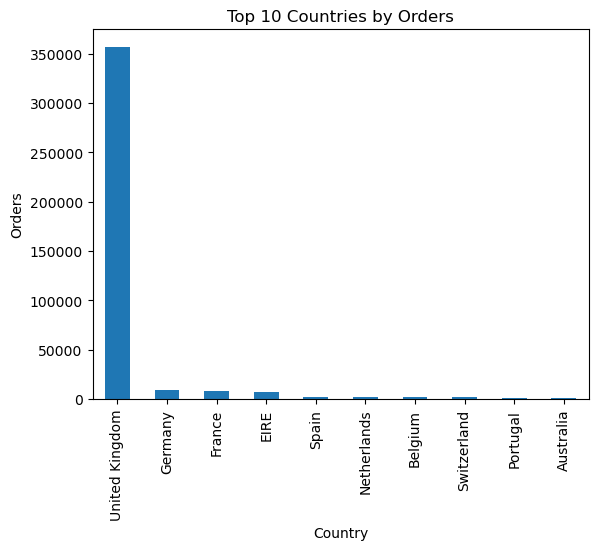

In [44]:
df['country'].value_counts().head(10).plot(kind='bar')

plt.title("Top 10 Countries by Orders")
plt.xlabel("Country")
plt.ylabel("Orders")

plt.show()

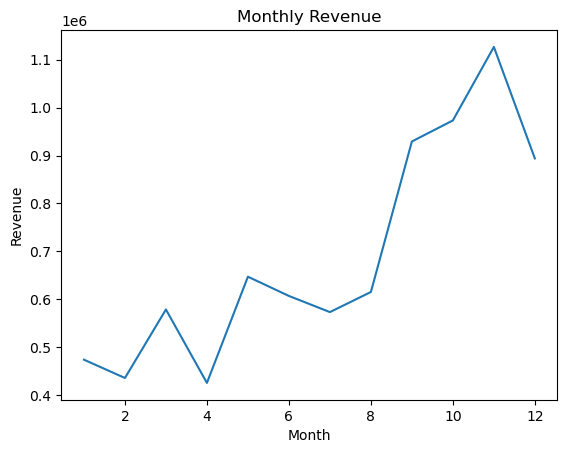

In [45]:
monthly_sales.plot(kind='line')

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

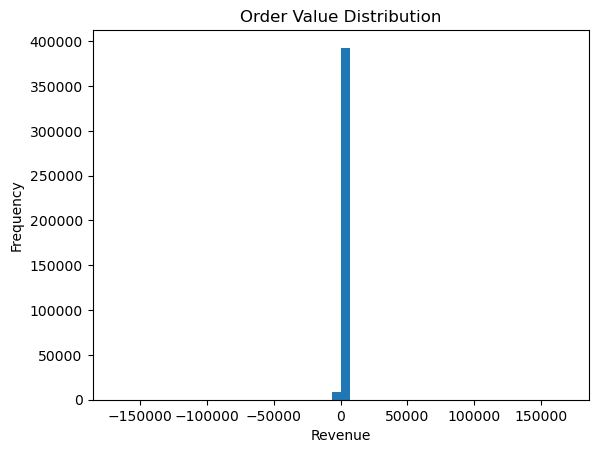

In [46]:
plt.hist(df['revenue'], bins=50)

plt.title("Order Value Distribution")
plt.xlabel("Revenue")
plt.ylabel("Frequency")

plt.show()

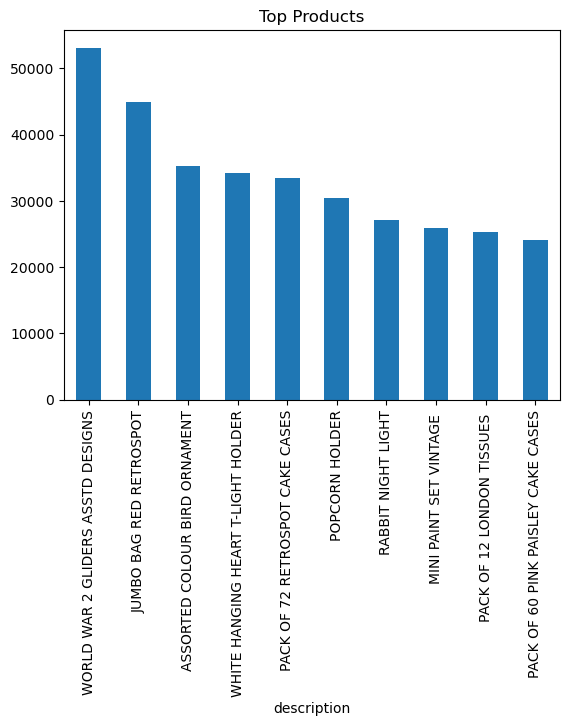

In [47]:
df.groupby('description')['quantity'].sum().sort_values(ascending=False).head(10).plot(kind='bar')

plt.title("Top Products")
plt.show()

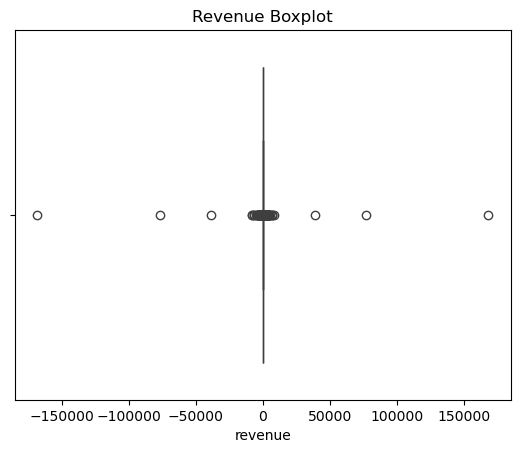

In [48]:
sns.boxplot(x=df['revenue'])

plt.title("Revenue Boxplot")

plt.show()

Insight 1:

The United Kingdom has the highest number of orders, showing it is the company's strongest market.


Insight 2:

Some products sell much more than others, showing customers prefer certain items.


Insight 3:

Monthly revenue changes over time, showing possible seasonal buying patterns.

Insight 4:

Most orders have lower values, meaning many customers make small purchases.

Insight 5:

Negative quantities show that some products were returned or cancelled.

RECOMMENDATIONS:

Recommendation 1

Focus on the biggest customer markets because they generate the most orders.

Recommendation 2

Increase stock before high sales months to avoid shortages.

Recommendation 3

Investigate low-selling products and improve marketing or remove them

REFLECTION:
This project helped me understand how data analysis can be used to find useful business information from raw data. I learned that cleaning the dataset is an important step because missing values, duplicates, and incorrect data can affect the results. I was surprised to see that some countries and products contributed much more to sales than others, showing that customer behaviour is not evenly distributed. The hardest part was preparing the data and creating the visualisations, but it helped me understand how charts make patterns easier to see. If I had more time, I would investigate customer buying behaviour further and build a model to predict future sales trends.
